# Underfitting vs Overfitting Visualized
### The Goldilocks Problem in Machine Learning

**Model Complexity:**
- Too simple → Underfitting
- Just right → Good generalization
- Too complex → Overfitting

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import seaborn as sns

plt.style.use('dark_background')
sns.set_palette("bright")
np.random.seed(42)

## 1. Generate Data
**True function: y = sin(x) + noise**

In [2]:
# Generate training data
n_samples = 30
X_train = np.sort(np.random.uniform(0, 10, n_samples))
y_train = np.sin(X_train) + np.random.normal(0, 0.2, n_samples)

# Generate test data
X_test = np.linspace(0, 10, 100)
y_test_true = np.sin(X_test)

print(f"Training samples: {n_samples}")
print(f"True function: y = sin(x) + noise")

Training samples: 30
True function: y = sin(x) + noise


## 2. The Three Models
**Polynomial regression with different degrees**

In [3]:
# Train three models with different complexities
degrees = [1, 6, 15]  # Underfitting, Good, Overfitting
models = {}

for degree in degrees:
    # Create polynomial features
    poly = PolynomialFeatures(degree=degree)
    X_poly = poly.fit_transform(X_train.reshape(-1, 1))
    
    # Train model
    model = LinearRegression()
    model.fit(X_poly, y_train)
    
    # Make predictions
    X_test_poly = poly.transform(X_test.reshape(-1, 1))
    y_pred = model.predict(X_test_poly)
    
    # Calculate errors
    train_pred = model.predict(X_poly)
    train_error = mean_squared_error(y_train, train_pred)
    test_error = mean_squared_error(y_test_true, y_pred)
    
    models[degree] = {
        'predictions': y_pred,
        'train_error': train_error,
        'test_error': test_error
    }
    
    print(f"Degree {degree:2d}: Train Error = {train_error:.4f}, Test Error = {test_error:.4f}")

Degree  1: Train Error = 0.4567, Test Error = 0.4465
Degree  6: Train Error = 0.0264, Test Error = 0.0130
Degree 15: Train Error = 0.0635, Test Error = 0.3785


## 3. Visual Comparison
**See the difference!**

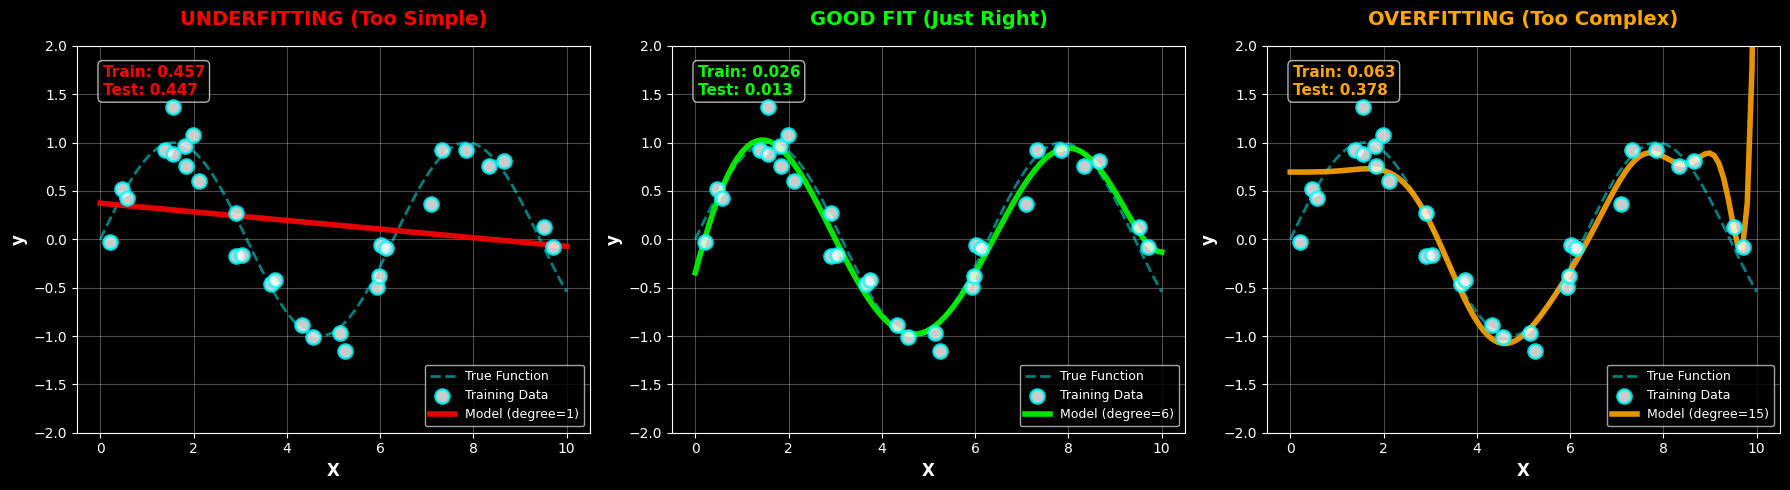


UNDERFITTING: Model too simple, misses pattern (high bias)
GOOD FIT: Captures pattern, generalizes well
OVERFITTING: Memorizes noise, fails on new data (high variance)


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
titles = ['UNDERFITTING (Too Simple)', 'GOOD FIT (Just Right)', 'OVERFITTING (Too Complex)']
colors = ['red', 'lime', 'orange']

for ax, degree, title, color in zip(axes, degrees, titles, colors):
    # Plot true function
    ax.plot(X_test, y_test_true, 'cyan', linewidth=2, alpha=0.5, 
           linestyle='--', label='True Function')
    
    # Plot training data
    ax.scatter(X_train, y_train, s=100, c='white', edgecolors='cyan', 
              linewidth=2, zorder=5, label='Training Data', alpha=0.8)
    
    # Plot model prediction
    ax.plot(X_test, models[degree]['predictions'], color=color, 
           linewidth=4, label=f'Model (degree={degree})', alpha=0.9)
    
    # Error text
    error_text = f"Train: {models[degree]['train_error']:.3f}\nTest: {models[degree]['test_error']:.3f}"
    ax.text(0.05, 0.95, error_text, transform=ax.transAxes, 
           fontsize=11, verticalalignment='top', fontweight='bold',
           bbox=dict(boxstyle='round', facecolor='black', alpha=0.7),
           color=color)
    
    ax.set_xlabel('X', fontsize=12, fontweight='bold')
    ax.set_ylabel('y', fontsize=12, fontweight='bold')
    ax.set_title(title, fontsize=14, fontweight='bold', color=color, pad=15)
    ax.legend(fontsize=9, loc='lower right')
    ax.grid(alpha=0.3)
    ax.set_ylim([-2, 2])

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("UNDERFITTING: Model too simple, misses pattern (high bias)")
print("GOOD FIT: Captures pattern, generalizes well")
print("OVERFITTING: Memorizes noise, fails on new data (high variance)")
print("="*60)

## 4. Training vs Validation Error
**The telltale curves**

In [5]:
# Test multiple model complexities
degree_range = range(1, 20)
train_errors = []
test_errors = []

for degree in degree_range:
    poly = PolynomialFeatures(degree=degree)
    X_poly = poly.fit_transform(X_train.reshape(-1, 1))
    
    model = LinearRegression()
    model.fit(X_poly, y_train)
    
    # Training error
    train_pred = model.predict(X_poly)
    train_errors.append(mean_squared_error(y_train, train_pred))
    
    # Test error
    X_test_poly = poly.transform(X_test.reshape(-1, 1))
    test_pred = model.predict(X_test_poly)
    test_errors.append(mean_squared_error(y_test_true, test_pred))

# Find optimal degree
optimal_degree = degree_range[np.argmin(test_errors)]

# Plot
fig, ax = plt.subplots(figsize=(12, 7))

ax.plot(degree_range, train_errors, 'cyan', linewidth=3, 
       marker='o', markersize=6, label='Training Error', alpha=0.8)
ax.plot(degree_range, test_errors, 'magenta', linewidth=3, 
       marker='s', markersize=6, label='Test Error', alpha=0.8)

# Mark optimal point
ax.scatter(optimal_degree, test_errors[optimal_degree-1], 
          s=500, c='lime', marker='*', edgecolors='yellow', 
          linewidth=3, zorder=5, label=f'Optimal (degree={optimal_degree})')

# Shade regions
ax.axvspan(1, 5, alpha=0.2, color='red', label='Underfitting Zone')
ax.axvspan(5, 10, alpha=0.2, color='lime', label='Good Zone')
ax.axvspan(10, 19, alpha=0.2, color='orange', label='Overfitting Zone')

# Annotations
ax.annotate('High Bias\n(Too Simple)', xy=(2, 0.3), fontsize=12, 
           fontweight='bold', color='red', ha='center')
ax.annotate('Sweet Spot', xy=(7, 0.05), fontsize=12, 
           fontweight='bold', color='lime', ha='center')
ax.annotate('High Variance\n(Too Complex)', xy=(15, 0.5), fontsize=12, 
           fontweight='bold', color='orange', ha='center')

# Gap annotation
ax.annotate('', xy=(17, train_errors[-1]), xytext=(17, test_errors[-1]),
           arrowprops=dict(arrowstyle='<->', color='yellow', lw=2))
ax.text(17.5, (train_errors[-1] + test_errors[-1])/2, 'GAP\n(Overfit!)', 
       fontsize=11, fontweight='bold', color='yellow')

ax.set_xlabel('Model Complexity (Polynomial Degree)', fontsize=13, fontweight='bold')
ax.set_ylabel('Mean Squared Error', fontsize=13, fontweight='bold')
ax.set_title('Model Complexity vs Error: The Bias-Variance Tradeoff', 
            fontsize=16, fontweight='bold', pad=20)
ax.legend(fontsize=11, loc='upper right')
ax.grid(alpha=0.3)
ax.set_ylim([0, max(test_errors[:15])*1.1])

plt.tight_layout()
plt.show()

print(f"\nOptimal model complexity: Degree {optimal_degree}")
print(f"Minimum test error: {min(test_errors):.4f}")

/var/folders/62/mgtn51r97gl21dm8hd8ywt2h0000gq/T/ipykernel_1488/1556776589.py:65: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()



Optimal model complexity: Degree 8
Minimum test error: 0.0128


## 5. Key Diagnostic Signs

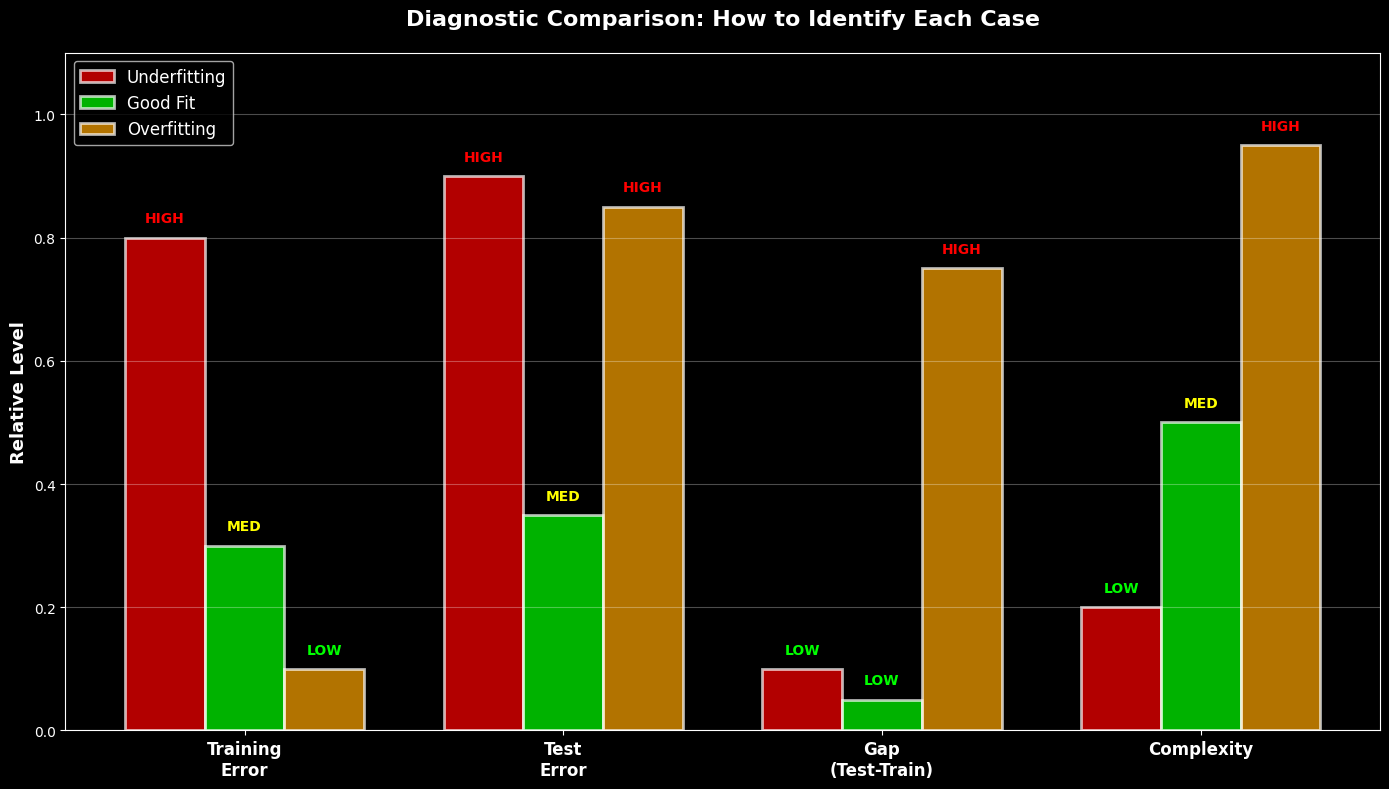


Diagnostic Guide:
UNDERFITTING:
  ✗ High training error
  ✗ High test error
  ✗ Small gap between train and test
  → Model too simple, increase complexity!

GOOD FIT:
  ✓ Low training error
  ✓ Low test error
  ✓ Small gap between train and test
  → Perfect! Ship it!

OVERFITTING:
  ✗ Very low training error
  ✗ High test error
  ✗ LARGE gap between train and test
  → Memorizing training data, reduce complexity!


In [6]:
# Create diagnostic comparison
fig, ax = plt.subplots(figsize=(14, 8))

# Data for comparison
categories = ['Training\nError', 'Test\nError', 'Gap\n(Test-Train)', 'Complexity']
x_pos = np.arange(len(categories))

# Normalized values for visualization
underfit_vals = [0.8, 0.9, 0.1, 0.2]  # High train, high test, small gap, low complexity
goodfit_vals = [0.3, 0.35, 0.05, 0.5]  # Low train, low test, small gap, medium complexity
overfit_vals = [0.1, 0.85, 0.75, 0.95]  # Very low train, high test, large gap, high complexity

width = 0.25

bars1 = ax.bar(x_pos - width, underfit_vals, width, label='Underfitting', 
              color='red', alpha=0.7, edgecolor='white', linewidth=2)
bars2 = ax.bar(x_pos, goodfit_vals, width, label='Good Fit', 
              color='lime', alpha=0.7, edgecolor='white', linewidth=2)
bars3 = ax.bar(x_pos + width, overfit_vals, width, label='Overfitting', 
              color='orange', alpha=0.7, edgecolor='white', linewidth=2)

# Add value labels
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        if height > 0.5:
            label = 'HIGH'
            color = 'red'
        elif height < 0.3:
            label = 'LOW'
            color = 'lime'
        else:
            label = 'MED'
            color = 'yellow'
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.02,
               label, ha='center', va='bottom', fontsize=10, 
               fontweight='bold', color=color)

ax.set_ylabel('Relative Level', fontsize=13, fontweight='bold')
ax.set_title('Diagnostic Comparison: How to Identify Each Case', 
            fontsize=16, fontweight='bold', pad=20)
ax.set_xticks(x_pos)
ax.set_xticklabels(categories, fontsize=12, fontweight='bold')
ax.legend(fontsize=12, loc='upper left')
ax.grid(axis='y', alpha=0.3)
ax.set_ylim([0, 1.1])

plt.tight_layout()
plt.show()

print("\nDiagnostic Guide:")
print("="*60)
print("UNDERFITTING:")
print("  ✗ High training error")
print("  ✗ High test error")
print("  ✗ Small gap between train and test")
print("  → Model too simple, increase complexity!\n")

print("GOOD FIT:")
print("  ✓ Low training error")
print("  ✓ Low test error")
print("  ✓ Small gap between train and test")
print("  → Perfect! Ship it!\n")

print("OVERFITTING:")
print("  ✗ Very low training error")
print("  ✗ High test error")
print("  ✗ LARGE gap between train and test")
print("  → Memorizing training data, reduce complexity!")
print("="*60)

## 6. Key Takeaways

### The Problem:
**Finding the right model complexity**

### Three States:

**1. UNDERFITTING (High Bias)**
- Model too simple
- Doesn't capture patterns
- High training error
- High test error
- Solution: Increase complexity

**2. GOOD FIT (Sweet Spot)**
- Appropriate complexity
- Captures true patterns
- Low training error
- Low test error
- Small gap between train/test

**3. OVERFITTING (High Variance)**
- Model too complex
- Memorizes noise
- Very low training error
- High test error
- Large gap between train/test
- Solution: Reduce complexity or regularize

### How to Fix:

**For Underfitting:**
- Add more features
- Increase model complexity
- Train longer
- Reduce regularization

**For Overfitting:**
- Get more training data
- Reduce model complexity
- Use regularization (L1/L2)
- Apply dropout
- Early stopping
- Data augmentation

### Remember:
**The goal is generalization, not memorization!**

Train error ≈ Test error = Good model! ✓